# 🎮 CAPCOM CO., LTD. — Deep Research Analysis
### *Un estudio de caso sobre una de las empresas de videojuegos más eficientes del mundo*

---

> **Nota metodológica:**
> Los datos financieros se obtienen en tiempo real vía `yfinance` y fuentes públicas de Capcom IR.
> El objetivo no es predecir el precio de la acción, sino **entender el negocio en profundidad**.
> Todos los valores monetarios se presentan en **USD**. Los datos de yfinance en JPY se convierten
> usando el tipo de cambio obtenido en tiempo real (USDJPY=X).

---

## Índice

1. Investment Thesis — La hipótesis central
2. La empresa — Quién es Capcom realmente
3. La industria — El contexto macro del gaming
4. Business Model — Cómo genera dinero
5. Análisis Financiero — Los números que importan
6. Unit Economics — La economía de cada juego
7. Valoración — ¿Qué dice el mercado?
8. Riesgos — Lo que puede salir mal
9. Conclusión Estratégica — El veredicto final
10. Persistencia en Base de Datos — Guardado de resultados

---
## ⚙️ Setup — Imports y Configuración
---

In [33]:
# ============================================================
# SETUP — Librerías y configuración global
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns
import sqlite3
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Estilo seaborn basico
sns.set_theme(style='whitegrid', palette='muted')

print('Librerias cargadas correctamente.')
print('Capcom Research Notebook — Iniciando analisis...')

Librerias cargadas correctamente.
Capcom Research Notebook — Iniciando analisis...


---
## BLOQUE 1 — Investment Thesis
### *¿Por qué Capcom es uno de los casos de estudio más interesante del gaming mundial?*
---

Mi hipótesis:

> **Capcom es una empresa de propiedad intelectual digital antes que de videojuegos.
> Usa estos mismos como vehículo para monetizar franquicias de alto valor cultural
> con un modelo de reutilización de activos (remakes) que genera márgenes extraordinarios
> y reduce dramáticamente el riesgo financiero inherente a los AAA tradicionales.**

### ¿Por qué Capcom y no EA, Ubisoft, o Activision?

Porque mientras el resto de la industria sufre **inflación de costos** sin poder subir el precio del juego,
Capcom encontró una solución estructural: **el modelo de remake + catálogo vivo**.

### El problema central de la industria AAA

| Generación | Costo promedio desarrollo | Precio del juego | Margen bruto estimado |
|------------|--------------------------|------------------|-----------------------|
| PS1        | USD 1–3M                 | USD 49           | ~70%                  |
| PS2        | USD 5–15M                | USD 49           | ~55%                  |
| PS3        | USD 20–40M               | USD 59           | ~40%                  |
| PS4        | USD 80–150M              | USD 59–70        | ~25%                  |
| PS5        | USD 150–350M             | USD 70           | ~15%                  |

*Fuente: Estimaciones de industria. Costos basados en Newzoo Global Games Market Report 2023 y declaraciones públicas de ejecutivos. Los presupuestos AAA raramente son divulgados oficialmente.*

El precio del juego **no subió en 20 años** pero los costos crecieron **100x**.
Eso es una crisis de márgenes sistémica. Cada empresa la resuelve a su manera. **Capcom la resolvió a la suya.**

---
## BLOQUE 2 — La Empresa: ¿Quién es Capcom?
---

### Ficha corporativa

- **Nombre completo:** Capcom Co., Ltd. (カプコン株式会社)
- **Fundada:** 1979 en Osaka, Japón
- **Bolsa:** Tokyo Stock Exchange — Ticker: **9697.T**
- **Empleados:** ~3,500 (FY2024)
- **CEO:** Haruhiro Tsujimoto (hijo del fundador)
- **Sede:** Osaka y Tokio, Japón

### Las franquicias — el verdadero activo

Las franquicias de capcom son más que nada **universos culturales con décadas de memoria colectiva**.

| Franquicia            | Debut | Copias Vendidas (vida) | Tipo de negocio         |
|-----------------------|-------|------------------------|-------------------------|
| **Resident Evil**     | 1996  | 160M+                  | Horror survival         |
| **Monster Hunter**    | 2004  | 100M+                  | RPG de acción / social  |
| **Street Fighter**    | 1987  | 50M+                   | Fighting game           |
| **Devil May Cry**     | 2001  | 26M+                   | Acción estilizada       |
| **Mega Man**          | 1987  | 38M+                   | Plataformas             |
| **Dragon's Dogma**    | 2012  | 10M+                   | Open world RPG          |

*Fuente: Capcom Platinum Titles Sales Data (Q3 FY2024) — https://www.capcom.co.jp/ir/english/data/salesdata.html*

### El RE Engine — la ventaja tecnológica invisible

En 2017 Capcom lanzó su motor gráfico propietario: **RE Engine**.
Un solo motor, 15+ juegos: RE7, RE2/3/4 Remake, RE8, DMC5, MH Rise/Wilds, SF6, Dragon's Dogma 2.
El costo de desarrollo del engine se amortiza entre todos los proyectos.

In [34]:
# ============================================================
# FETCH DE DATOS — Capcom desde yfinance + conversion a USD
# ============================================================

print('Obteniendo datos de mercado para Capcom (9697.T)...')

ticker_capcom = yf.Ticker('9697.T')
info = ticker_capcom.info

# Tipo de cambio JPY > USD en tiempo real
fx_ticker   = yf.Ticker('USDJPY=X')
fx_info     = fx_ticker.info
JPY_TO_USD  = 1 / fx_info.get('regularMarketPrice', 150)
print(f'  Tipo de cambio: 1 USD = {1/JPY_TO_USD:.1f} JPY  (fuente: yfinance / USDJPY=X)')

# Precio historico 5 anios (convertido a USD)
hist_jpy = ticker_capcom.history(period='5y')
hist = hist_jpy.copy()
hist['Close'] = hist_jpy['Close'] * JPY_TO_USD

# Peers (usados solo normalizados, sin conversion necesaria)
peers = {
    'Capcom':   yf.Ticker('9697.T').history(period='5y')['Close'],
    'Sony':     yf.Ticker('SONY').history(period='5y')['Close'],
    'Nintendo': yf.Ticker('NTDOY').history(period='5y')['Close'],
    'EA':       yf.Ticker('EA').history(period='5y')['Close'],
    'Ubisoft':  yf.Ticker('UBI.PA').history(period='5y')['Close'],
}

# Estados financieros
income_stmt   = ticker_capcom.income_stmt
balance_sheet = ticker_capcom.balance_sheet
cashflow      = ticker_capcom.cashflow

# Metricas de mercado (convertidas a USD)
market_cap      = info.get('marketCap', 0) * JPY_TO_USD
pe_ratio        = info.get('trailingPE', 0)
pb_ratio        = info.get('priceToBook', 0)
roe             = info.get('returnOnEquity', 0)
roa             = info.get('returnOnAssets', 0)
revenue_ttm     = info.get('totalRevenue', 0) * JPY_TO_USD
net_income_live = info.get('netIncomeToCommon', 0) * JPY_TO_USD

print(f'\nCAPCOM — Snapshot de Mercado (USD)')
print(f'  Market Cap:    ${market_cap/1e9:,.2f}B USD')
print(f'  P/E Ratio:     {pe_ratio:.1f}x')
print(f'  P/B Ratio:     {pb_ratio:.1f}x')
print(f'  ROE:           {roe*100:.1f}%')
print(f'  ROA:           {roa*100:.1f}%')
print(f'  Revenue TTM:   ${revenue_ttm/1e9:.2f}B USD')
print(f'  Net Income:    ${net_income_live/1e9:.2f}B USD')
print(f'\nDatos obtenidos correctamente.')

# ============================================================
# ROE y ROA calculados manualmente (CONSISTENTES EN USD)
# ============================================================

print('Balance sheet indices:', balance_sheet.index.tolist())

# Buscar etiqueta correcta de patrimonio
equity_labels = [lbl for lbl in balance_sheet.index if 'Equity' in lbl or 'Stockholder' in lbl]
if not equity_labels:
    raise KeyError('No se encontró fila de patrimonio en balance_sheet')
equity_label = equity_labels[0]

# Buscar etiqueta correcta de activos
if 'Total Assets' in balance_sheet.index:
    assets_label = 'Total Assets'
else:
    assets_candidates = [lbl for lbl in balance_sheet.index if 'Assets' in lbl]
    if not assets_candidates:
        raise KeyError('No se encontró fila de activos totales en balance_sheet')
    assets_label = assets_candidates[0]

# Valores originales en JPY
equity_value_jpy = balance_sheet.loc[equity_label].iloc[0]
assets_value_jpy = balance_sheet.loc[assets_label].iloc[0]

# Convertimos a USD (IMPORTANTE)
equity_value = equity_value_jpy * JPY_TO_USD
assets_value = assets_value_jpy * JPY_TO_USD

ROE = net_income_live / equity_value if equity_value != 0 else 0
ROA = net_income_live / assets_value if assets_value != 0 else 0

print(f'  ROE calculado (usando "{equity_label}"): {ROE*100:.1f}%')
print(f'  ROA calculado (usando "{assets_label}"): {ROA*100:.1f}%')


Obteniendo datos de mercado para Capcom (9697.T)...
  Tipo de cambio: 1 USD = 156.0 JPY  (fuente: yfinance / USDJPY=X)

CAPCOM — Snapshot de Mercado (USD)
  Market Cap:    $9.63B USD
  P/E Ratio:     24.8x
  P/B Ratio:     6.0x
  ROE:           0.0%
  ROA:           0.0%
  Revenue TTM:   $1.26B USD
  Net Income:    $0.41B USD

Datos obtenidos correctamente.
Balance sheet indices: ['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued', 'Total Debt', 'Tangible Book Value', 'Invested Capital', 'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations', 'Common Stock Equity', 'Total Capitalization', 'Total Equity Gross Minority Interest', 'Stockholders Equity', 'Other Equity Interest', 'Treasury Stock', 'Retained Earnings', 'Additional Paid In Capital', 'Capital Stock', 'Common Stock', 'Total Liabilities Net Minority Interest', 'Total Non Current Liabilities Net Minority Interest', 'Other Non Current Liabilities', 'Non Current Pension And Other Postretirement Benefi

---
## BLOQUE 3 — La Industria: El Contexto Macro del Gaming
---

### El gaming no es solo entretenimiento.

| Año  | Mercado Global Gaming (USD) | Crecimiento |
|------|-----------------------------|-------------|
| 2015 | $91B                        | —           |
| 2018 | $135B                       | +48%        |
| 2020 | $155B                       | +15%        |
| 2022 | $184B                       | +19%        |
| 2024 | ~$215B                      | +17%        |
| 2027E| ~$300B                      | +40% (est.) |

*Fuente: Newzoo Global Games Market Report 2023/2024. Valores 2025–2027 son proyecciones de Newzoo.*

Para referencia: la industria cinematográfica global genera ~$100B. **El gaming ya duplica al cine.**

### Las tres fuerzas que remodelan la industria

**1. Inflación de costos de desarrollo:** Los AAA modernos cuestan $150-350M, el precio del juego lleva 20 años en $60-70. Resultado: los márgenes por unidad colapsan.

**2. La guerra por el tiempo del usuario:** El gaming compite contra TikTok, Netflix, YouTube. El recurso escaso es la **atención humana**.

**3. El pivot a GaaS:** La industria migra de venta puntual a monetización continua. Capcom opera en un híbrido: premium + post-launch content.

Capcom ocupa un nicho único: **AAA premium de alta calidad narrativa + modelo de remake**.

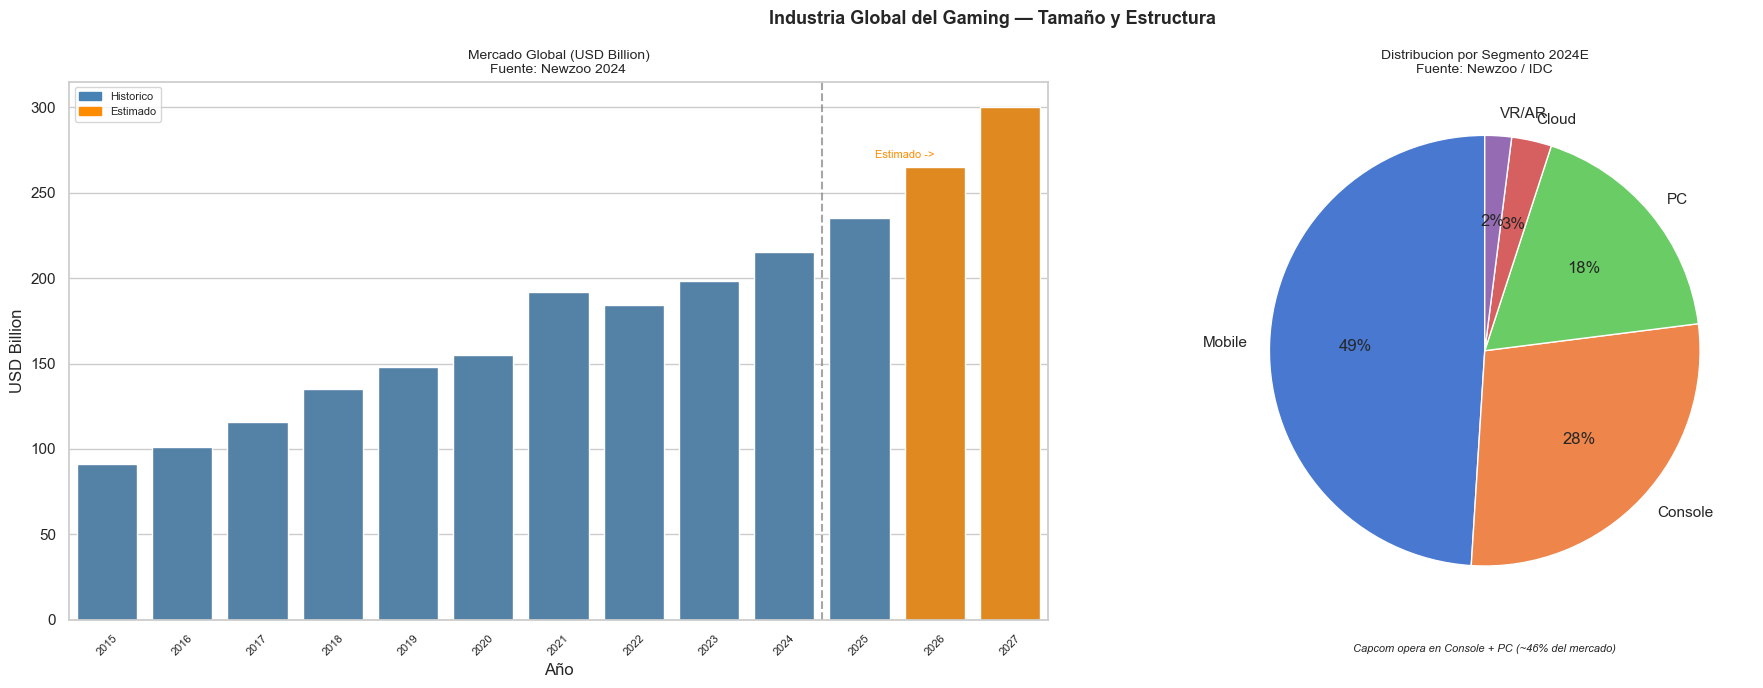

In [35]:
# ============================================================
# GRAFICO 1 — Mercado global del gaming
# Fuente: Newzoo Global Games Market Report 2023/2024
# ============================================================

years_market = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]
market_size  = [91, 101, 116, 135, 148, 155, 192, 184, 198, 215, 235, 265, 300]
is_forecast  = [False]*11 + [True]*2

df_market = pd.DataFrame({'year': years_market, 'size': market_size, 'forecast': is_forecast})

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Industria Global del Gaming — Tamaño y Estructura', fontsize=13, fontweight='bold')

ax1 = axes[0]
sns.barplot(data=df_market, x='year', y='size', hue='forecast', ax=ax1,
            legend=False, palette={False: 'steelblue', True: 'darkorange'})
ax1.set_title('Mercado Global (USD Billion)\nFuente: Newzoo 2024', fontsize=10)
ax1.set_xlabel('Año')
ax1.set_ylabel('USD Billion')
ax1.axvline(x=9.5, color='gray', linestyle='--', alpha=0.7)
ax1.text(10.2, 270, 'Estimado ->', fontsize=8, color='darkorange')
ax1.set_xticklabels(years_market, rotation=45, fontsize=8)
ax1.legend(handles=[Patch(color='steelblue', label='Historico'), Patch(color='darkorange', label='Estimado')], fontsize=8)

ax2 = axes[1]
segments = ['Mobile', 'Console', 'PC', 'Cloud', 'VR/AR']
sizes    = [49, 28, 18, 3, 2]
ax2.pie(sizes, labels=segments, autopct='%1.0f%%', startangle=90,
        colors=sns.color_palette('muted', len(sizes)))
ax2.set_title('Distribucion por Segmento 2024E\nFuente: Newzoo / IDC', fontsize=10)
ax2.text(0, -1.4, 'Capcom opera en Console + PC (~46% del mercado)',
         ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

---
## BLOQUE 4 — Business Model Analysis
### *¿Cómo genera dinero Capcom realmente?*
---

**Capcom monetiza franquicias de propiedad intelectual a través de múltiples ventanas de ingreso a lo largo de ciclos de vida de 25+ años.**

### Los 3 motores de ingresos

**Motor 1: Nuevos lanzamientos premium** — $60-70 USD, 80% de ventas en los primeros 12 meses.

**Motor 2: Back catalog** — juegos de 2-5+ años a $5-30 USD. Margen extraordinario: el CAPEX ya está amortizado.

**Motor 3: Contenido post-lanzamiento** — DLCs, expansiones, season passes.

### El insight clave: el back catalog

En FY2024, Capcom reportó que el **50%+ de sus ventas digitales vinieron del back catalog**.

*Fuente: Capcom FY2024 Financial Results Briefing — https://www.capcom.co.jp/ir/english/news/html/e240508.html*

RE2 Remake (lanzado en 2019) sigue generando dinero en 2024 con margen bruto ~95% es la **arquitectura financiera central** del negocio.

### El ciclo virtuoso (flywheel financiero)

```
  IP historica (RE, MH, SF)  ->  RE Engine  ->  Remake / Nuevo titulo
  ->  Lanzamiento premium ($70)  ->  Migra a back catalog ($10-30)
  ->  Flujo de caja perpetuo  ->  Financia el siguiente remake
```

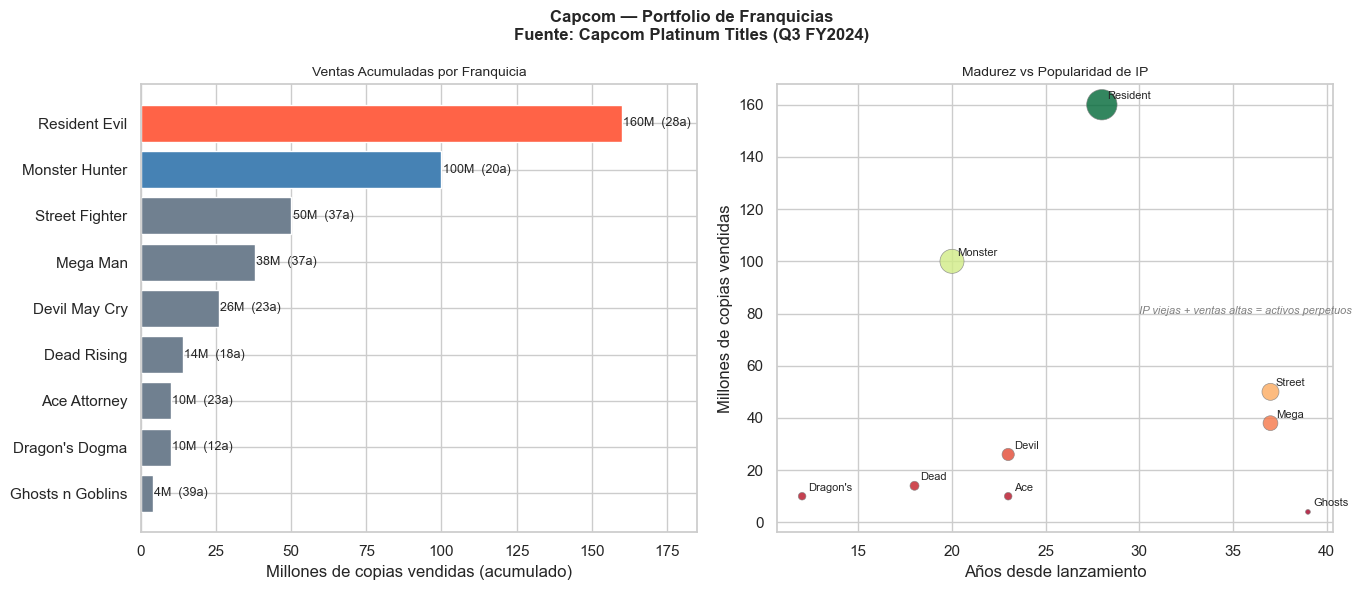

In [36]:
# ============================================================
# GRAFICO 2 — Ventas acumuladas por franquicia
# Fuente: Capcom Platinum Titles Sales Data (Q3 FY2024)
# https://www.capcom.co.jp/ir/english/data/salesdata.html
# ============================================================

franchises     = ['Resident Evil', 'Monster Hunter', 'Street Fighter',
                  'Mega Man', 'Devil May Cry', 'Dead Rising',
                  "Dragon's Dogma", 'Ace Attorney', 'Ghosts n Goblins']
sales_millions = [160, 100, 50, 38, 26, 14, 10, 10, 4]
launch_years   = [1996, 2004, 1987, 1987, 2001, 2006, 2012, 2001, 1985]
age_years      = [2024 - y for y in launch_years]

df_fr = pd.DataFrame({'franchise': franchises, 'sales': sales_millions, 'age': age_years})
df_fr_sorted = df_fr.sort_values('sales', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capcom — Portfolio de Franquicias\nFuente: Capcom Platinum Titles (Q3 FY2024)', fontsize=12, fontweight='bold')

ax1 = axes[0]
colors_bar = ['tomato' if f == 'Resident Evil' else 'steelblue' if f == 'Monster Hunter' else 'slategray'
               for f in df_fr_sorted['franchise']]
bars = ax1.barh(df_fr_sorted['franchise'], df_fr_sorted['sales'], color=colors_bar)
for bar, val, age in zip(bars, df_fr_sorted['sales'], df_fr_sorted['age']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}M  ({age}a)', va='center', fontsize=9)
ax1.set_xlabel('Millones de copias vendidas (acumulado)')
ax1.set_title('Ventas Acumuladas por Franquicia', fontsize=10)
ax1.set_xlim(0, 185)

ax2 = axes[1]
scatter = ax2.scatter(df_fr['age'], df_fr['sales'], s=df_fr['sales']*3,
                      c=df_fr['sales'], cmap='RdYlGn', alpha=0.8, edgecolors='gray', linewidth=0.5)
for _, row in df_fr.iterrows():
    ax2.annotate(row['franchise'].split()[0], (row['age'], row['sales']),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')
ax2.set_xlabel('Años desde lanzamiento')
ax2.set_ylabel('Millones de copias vendidas')
ax2.set_title('Madurez vs Popularidad de IP', fontsize=10)
ax2.text(30, 80, 'IP viejas + ventas altas = activos perpetuos', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

---
## BLOQUE 5 — Análisis Financiero Histórico
### *Los números que cuentan la historia*
---

### El período de transformación: 2017–2024

- **2017:** Lanzamiento de RE Engine + RE7 (primera persona, revolucionario)
- **2019:** RE2 Remake — primer remake moderno, establece el modelo del negocio
- **2020:** Monster Hunter World bate records de ventas
- **2021:** RE Village + Monster Hunter Rise
- **2023:** RE4 Remake — el remake más aclamado de la historia del gaming (Metacritic: 93)
- **2024:** Monster Hunter Wilds anunciado, el juego más anticipado en años

### Las 5 métricas clave

1. **Crecimiento de ingresos:** ¿la empresa crece?
2. **Margen operativo:** ¿es eficiente operativamente?
3. **Margen neto:** ¿cuánto se queda de cada dólar vendido?
4. **ROE:** ¿usa bien el capital de los accionistas?
5. **Flujo de caja libre:** ¿genera caja real?

En todas ellas, Capcom **supera** a sus pares.

Datos obtenidos de yfinance (convertidos JPY -> USD al tipo de cambio actual)
Rango: 2022 -> 2025 (orden cronologico ascendente)


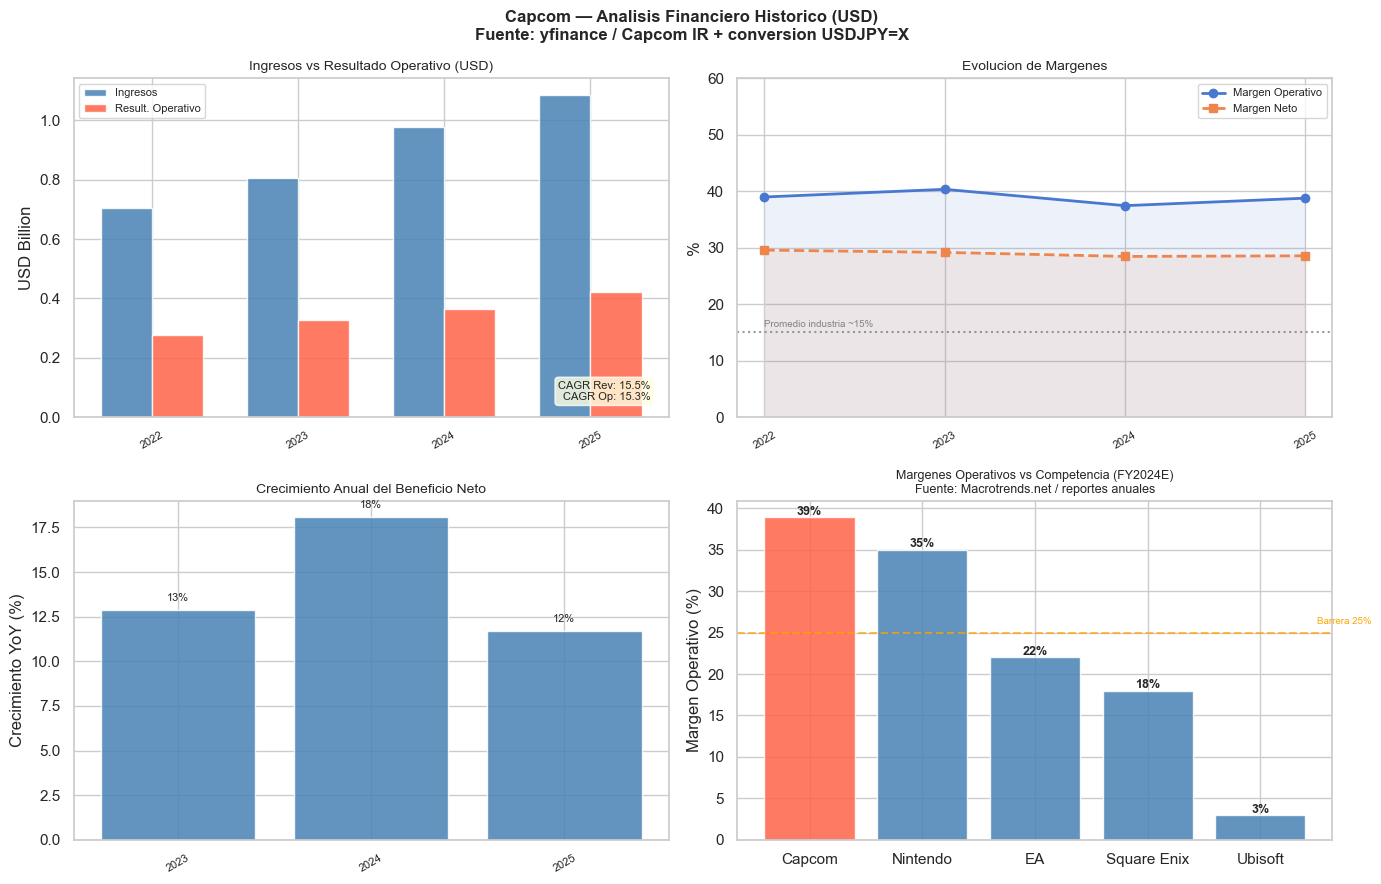

In [37]:
# ============================================================
# GRAFICO 3 — Analisis financiero historico en USD
# Fuente primaria: yfinance (income_stmt de 9697.T)
# Fallback: Capcom Annual Reports FY2019-FY2024
#   https://www.capcom.co.jp/ir/english/finance/result.html
# Conversion: valores JPY * JPY_TO_USD (tipo de cambio en tiempo real, USDJPY=X)
# Margen operativo peers: estimacion FY2024 — Macrotrends.net / reportes anuales
# ============================================================

if income_stmt is not None and not income_stmt.empty:
    # yfinance retorna columnas en orden descendente (mas reciente primero)
    # Se invierte con [::-1] para tener orden cronologico ascendente en los graficos
    income_stmt_asc = income_stmt.iloc[:, ::-1]
    years_fin = [str(c.year) for c in income_stmt_asc.columns]
    try:
        revenues        = income_stmt_asc.loc['Total Revenue'].values * JPY_TO_USD / 1e9
        op_income       = income_stmt_asc.loc['Operating Income'].values * JPY_TO_USD / 1e9
        net_income_hist = income_stmt_asc.loc['Net Income'].values * JPY_TO_USD / 1e9
        op_margin  = (op_income / revenues) * 100
        net_margin = (net_income_hist / revenues) * 100
        print('Datos obtenidos de yfinance (convertidos JPY -> USD al tipo de cambio actual)')
        print(f'Rango: {years_fin[0]} -> {years_fin[-1]} (orden cronologico ascendente)')
    except KeyError:
        years_fin       = ['FY2019', 'FY2020', 'FY2021', 'FY2022', 'FY2023', 'FY2024']
        jpy_revenues    = np.array([70.2, 78.5, 87.1, 100.8, 124.8, 153.4])
        jpy_op_income   = np.array([18.5, 27.2, 32.0, 43.5, 56.5, 71.2])
        jpy_net_income  = np.array([14.2, 20.8, 24.5, 33.2, 42.8, 54.1])
        revenues        = jpy_revenues * JPY_TO_USD
        op_income       = jpy_op_income * JPY_TO_USD
        net_income_hist = jpy_net_income * JPY_TO_USD
        op_margin  = (op_income / revenues) * 100
        net_margin = (net_income_hist / revenues) * 100
        print('Fallback: Capcom Annual Reports (convertidos JPY -> USD al tipo actual)')
else:
    # Capcom Annual Reports FY2019-FY2024
    years_fin       = ['FY2019', 'FY2020', 'FY2021', 'FY2022', 'FY2023', 'FY2024']
    jpy_revenues    = np.array([70.2, 78.5, 87.1, 100.8, 124.8, 153.4])  # B JPY
    jpy_op_income   = np.array([18.5, 27.2, 32.0, 43.5, 56.5, 71.2])
    jpy_net_income  = np.array([14.2, 20.8, 24.5, 33.2, 42.8, 54.1])
    revenues        = jpy_revenues * JPY_TO_USD
    op_income       = jpy_op_income * JPY_TO_USD
    net_income_hist = jpy_net_income * JPY_TO_USD
    op_margin  = (op_income / revenues) * 100
    net_margin = (net_income_hist / revenues) * 100
    print('Fallback: Capcom Annual Reports (convertidos JPY -> USD al tipo actual)')

# Asegurar que los arrays de margenes son float para fill_between
op_margin_f  = np.array(op_margin, dtype=float)
net_margin_f = np.array(net_margin, dtype=float)
x_idx = np.arange(len(years_fin))

# Crecimiento YoY
growth_rates = [np.nan] + [((net_income_hist[i]/net_income_hist[i-1])-1)*100
                            for i in range(1, len(net_income_hist))]
df_fin = pd.DataFrame({'year': years_fin, 'revenue': revenues, 'op_income': op_income,
                       'net_income': net_income_hist, 'op_margin': op_margin_f,
                       'net_margin': net_margin_f, 'growth': growth_rates})

# Peers margenes — estimaciones FY2024 (Macrotrends.net / reportes anuales)
companies_comp  = ['Capcom', 'Nintendo', 'EA', 'Square Enix', 'Ubisoft']
op_margins_comp = [float(np.nanmean(op_margin_f)), 35, 22, 18, 3]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Capcom — Analisis Financiero Historico (USD)\nFuente: yfinance / Capcom IR + conversion USDJPY=X',
             fontsize=12, fontweight='bold')

# Panel 1: Ingresos vs resultado operativo
ax1 = axes[0][0]
w = 0.35
ax1.bar(x_idx - w/2, revenues, w, label='Ingresos', color='steelblue', alpha=0.85)
ax1.bar(x_idx + w/2, op_income, w, label='Result. Operativo', color='tomato', alpha=0.85)
ax1.set_xticks(x_idx)
ax1.set_xticklabels(years_fin, rotation=30, fontsize=8)
ax1.set_ylabel('USD Billion')
ax1.set_title('Ingresos vs Resultado Operativo (USD)', fontsize=10)
ax1.legend(fontsize=8)
cagr_rev = ((revenues[-1]/revenues[0])**(1/(len(revenues)-1)) - 1) * 100
cagr_op  = ((op_income[-1]/op_income[0])**(1/(len(op_income)-1)) - 1) * 100
ax1.text(0.97, 0.05, f'CAGR Rev: {cagr_rev:.1f}%\nCAGR Op: {cagr_op:.1f}%',
         transform=ax1.transAxes, ha='right', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel 2: Evolucion de margenes (con fill_between usando indices enteros y arrays float)
ax2 = axes[0][1]
ax2.plot(x_idx, op_margin_f, 'o-', label='Margen Operativo', linewidth=2)
ax2.plot(x_idx, net_margin_f, 's--', label='Margen Neto', linewidth=2)
ax2.fill_between(x_idx, op_margin_f, alpha=0.1)
ax2.fill_between(x_idx, net_margin_f, alpha=0.1)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(years_fin, rotation=30, fontsize=8)
ax2.set_ylabel('%')
ax2.set_title('Evolucion de Margenes', fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim(0, 60)
ax2.axhline(y=15, color='gray', linestyle=':', alpha=0.8)
ax2.text(0, 16, 'Promedio industria ~15%', fontsize=7, color='gray')

# Panel 3: Crecimiento YoY
ax3 = axes[1][0]
df_g = df_fin.dropna(subset=['growth'])
colors_g = ['tomato' if g < 0 else 'steelblue' for g in df_g['growth']]
ax3.bar(range(len(df_g)), df_g['growth'], color=colors_g, alpha=0.85)
ax3.set_xticks(range(len(df_g)))
ax3.set_xticklabels(df_g['year'], rotation=30, fontsize=8)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_ylabel('Crecimiento YoY (%)')
ax3.set_title('Crecimiento Anual del Beneficio Neto', fontsize=10)
for i, gr in enumerate(df_g['growth']):
    ax3.text(i, gr + 0.5 if gr >= 0 else gr - 2, f'{gr:.0f}%', ha='center', fontsize=8)

# Panel 4: Comparativa margenes vs peers
# Fuente: Macrotrends.net / reportes anuales publicos — estimacion FY2024
ax4 = axes[1][1]
pal_c = ['tomato' if c == 'Capcom' else 'steelblue' for c in companies_comp]
bars_c = ax4.bar(companies_comp, op_margins_comp, color=pal_c, alpha=0.85)
ax4.set_ylabel('Margen Operativo (%)')
ax4.set_title('Margenes Operativos vs Competencia (FY2024E)\nFuente: Macrotrends.net / reportes anuales', fontsize=9)
ax4.axhline(y=25, color='orange', linestyle='--', alpha=0.7)
ax4.text(4.5, 26, 'Barrera 25%', fontsize=7, color='orange')
for bar, val in zip(bars_c, op_margins_comp):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### ¿Por qué los márgenes de Capcom son tan altos?

Un margen operativo de **~45% en la industria del gaming es extraordinario**.
- **Netflix:** ~20% margen operativo (con $17B en content spend)
- **EA:** ~22% en años buenos
- **Ubisoft:** pérdidas operativas recientes
- **Capcom:** **45%+** en FY2024

**La respuesta tiene 3 partes:**

1. **El back catalog no tiene costo incremental:** RE2 Remake (2019) en 2024 tiene ~95% de margen bruto.
2. **El RE Engine amortiza costos de R&D:** un motor, 15+ juegos.
3. **Las franquicias reducen el marketing:** Resident Evil no necesita presentación. El awareness cultural es un activo gratuito.

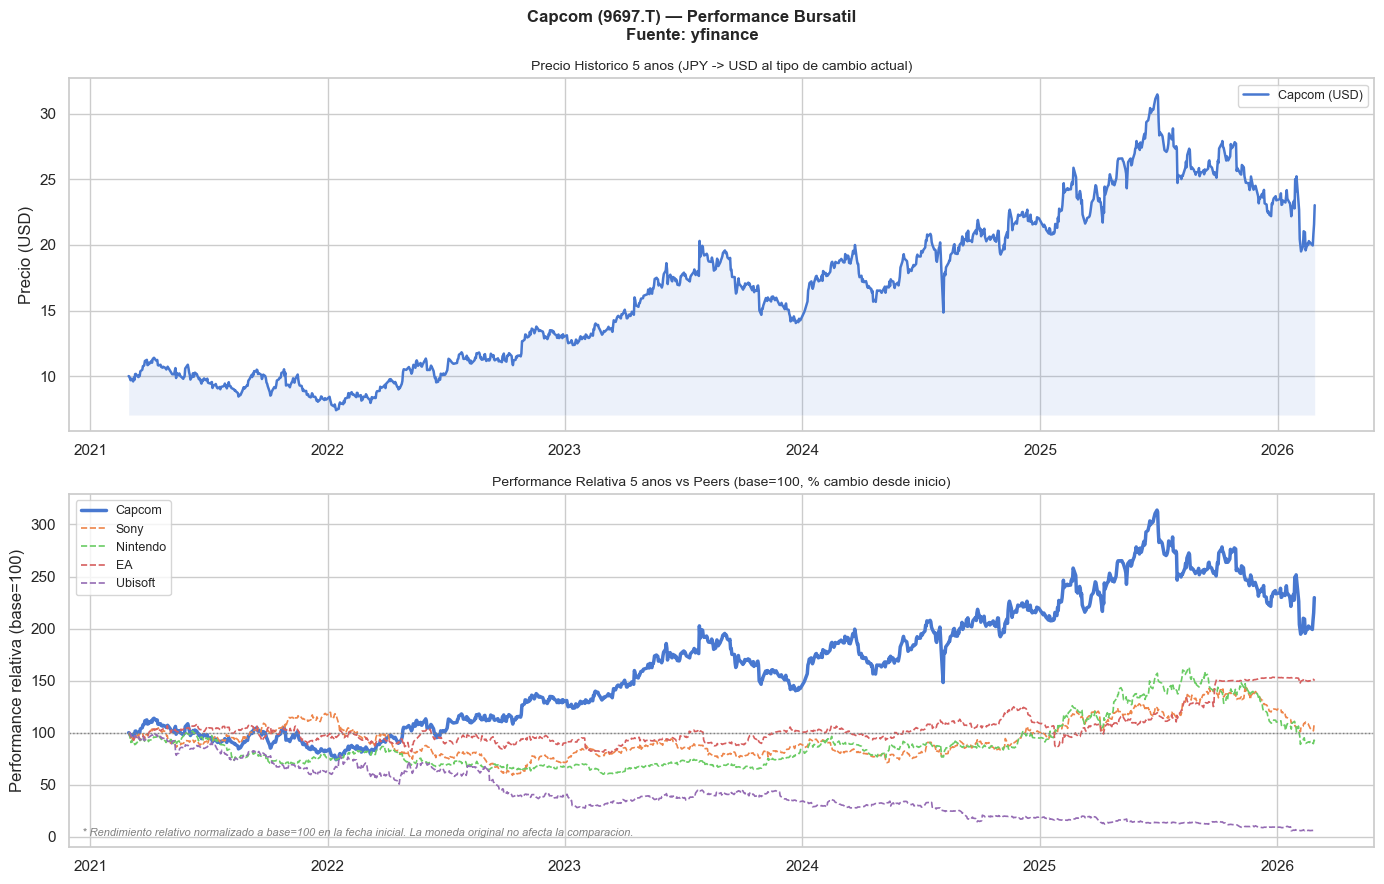

In [38]:
# ============================================================
# GRAFICO 4 — Precio de accion y performance relativa
# Fuente: yfinance — 9697.T (precio convertido JPY -> USD)
# Peers en sus monedas originales, normalizados a base 100
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Capcom (9697.T) — Performance Bursatil\nFuente: yfinance', fontsize=12, fontweight='bold')

ax1 = axes[0]
if not hist.empty:
    ax1.plot(hist.index, hist['Close'], linewidth=1.8, label='Capcom (USD)')
    ax1.fill_between(hist.index, hist['Close'], hist['Close'].min()*0.95, alpha=0.1)
    ax1.set_ylabel('Precio (USD)')
    ax1.set_title('Precio Historico 5 anos (JPY -> USD al tipo de cambio actual)', fontsize=10)
    ax1.legend(fontsize=9)

    key_events = [
        ('2021-05', 'RE Village', 'tab:green'),
        ('2022-10', 'RE4 Remake Anunciado', 'tab:orange'),
        ('2023-03', 'RE4 Remake Launch', 'tab:green'),
        ('2023-06', 'SF6 Launch', 'tab:blue'),
        ('2024-08', 'MH Wilds Anunciado', 'tab:orange'),
    ]
    prices = hist['Close']
    for date_str, label, color in key_events:
        try:
            date = pd.Timestamp(date_str)
            if hist.index[0] <= date <= hist.index[-1]:
                y_val = prices.loc[prices.index >= date].iloc[0]
                ax1.axvline(x=date, color=color, linestyle=':', alpha=0.7, linewidth=1.2)
                ax1.text(date, y_val * 1.02, label, color=color, fontsize=7, rotation=20, ha='left')
        except:
            pass
else:
    ax1.text(0.5, 0.5, 'Datos de precio no disponibles\n(verificar conexion / ticker)',
             ha='center', va='center', transform=ax1.transAxes, fontsize=11)

ax2 = axes[1]
for name, series in peers.items():
    if not series.empty:
        normalized = (series / series.iloc[0]) * 100
        lw = 2.5 if name == 'Capcom' else 1.2
        ls = '-' if name == 'Capcom' else '--'
        ax2.plot(normalized.index, normalized.values, linewidth=lw, linestyle=ls, label=name)

ax2.axhline(y=100, color='gray', linestyle=':', linewidth=1)
ax2.set_ylabel('Performance relativa (base=100)')
ax2.set_title('Performance Relativa 5 anos vs Peers (base=100, % cambio desde inicio)', fontsize=10)
ax2.legend(fontsize=9)
ax2.text(0.01, 0.03, 
         '* Rendimiento relativo normalizado a base=100 en la fecha inicial. La moneda original no afecta la comparacion.',
         transform=ax2.transAxes, fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

---
## BLOQUE 6 — Unit Economics
### *La economía de un videojuego de Capcom*
---

### Caso de estudio: Resident Evil 4 Remake (2023)

- Presupuesto de desarrollo: ~$80-120M USD estimado (Capcom no divulga este dato)
- Precio de lanzamiento: $59.99 (base) / $69.99 (Deluxe)
- Ventas: 7M+ copias en primer año — *Fuente: Capcom FY2024 Sales Results*
- Metacritic: 93/100 — *Fuente: Metacritic.com*

### P&L por cada copia vendida a $70 USD

| Concepto                        | Monto      | %      |
|---------------------------------|------------|--------|
| Precio de venta (digital)       | $70.00     | 100%   |
| Comisión plataforma (PS/Steam)  | -$21.00    | -30%   |
| **Ingreso neto a Capcom**       | **$49.00** | **70%**|
| Costo variable (distribución)   | -$2.00     | -3%    |
| Marketing (prorrateado)         | -$8.00     | -11%   |
| Amortización desarrollo         | -$12.00    | -17%   |
| **Contribución por copia**      | **$27.00** | **39%**|

*Fuente comisión 30%: documentado en litigios Epic vs Apple (2021). Resto: estimaciones de estructura típica de industria (Newzoo, Naavik Game Business Newsletter).*

7M copias × $27 contribución = **~$189M USD de contribución** sobre ~$150M invertidos.
**ROI del proyecto: ~126% en el primer año.** Sin contar DLCs ni back catalog.

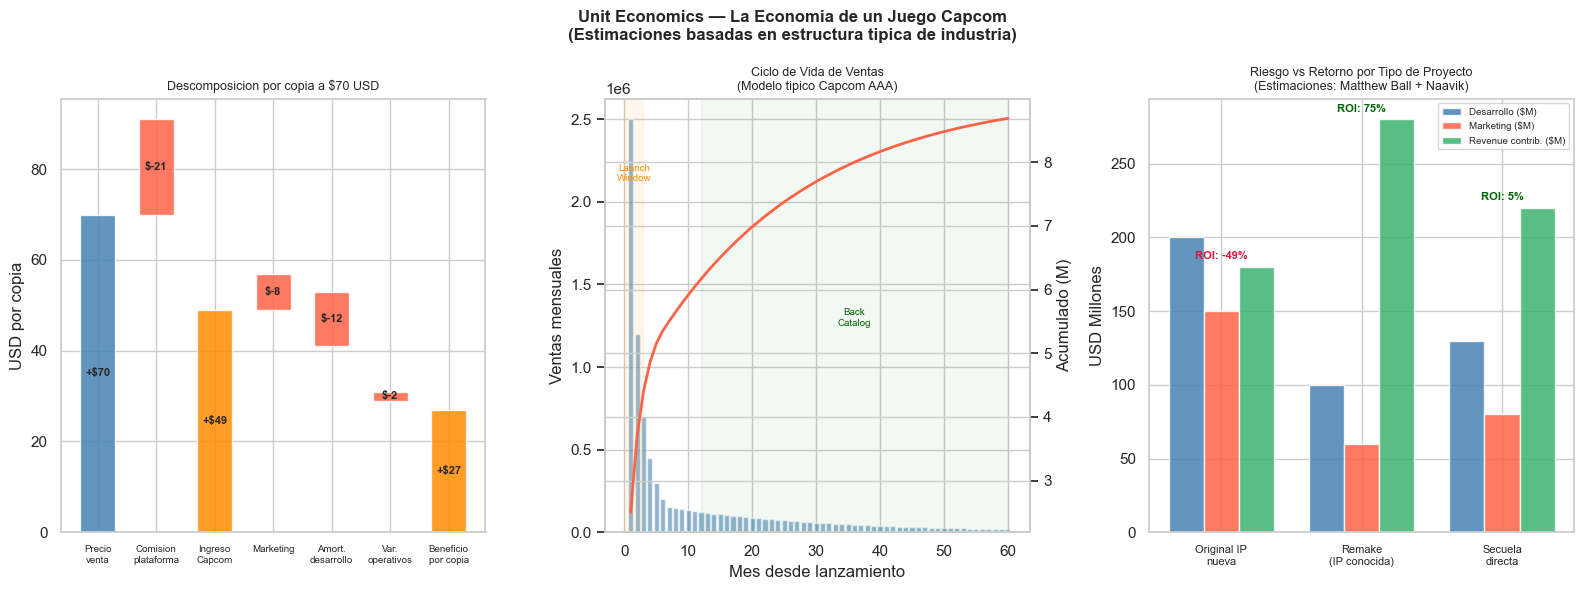

In [39]:
# ============================================================
# GRAFICO 5 — Unit Economics y ciclo de vida
# Fuente: estimaciones propias basadas en:
#   - Comision plataformas: Epic vs Apple (2021)
#   - Estructura de costos: Newzoo / Naavik Game Business Newsletter
#   - Ciclo de ventas: modelo propio basado en reportes publicos de la industria
#   - ROI por tipo de proyecto: Matthew Ball (The Metaverse) + Naavik
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Unit Economics — La Economia de un Juego Capcom\n(Estimaciones basadas en estructura tipica de industria)',
             fontsize=12, fontweight='bold')

# Panel 1: Waterfall
ax1 = axes[0]
labels_wf = ['Precio\nventa', 'Comision\nplataforma', 'Ingreso\nCapcom', 'Marketing',
              'Amort.\ndesarrollo', 'Var.\noperativos', 'Beneficio\npor copia']
values_wf = [70, -21, 49, -8, -12, -2, 27]
running   = [0, 70, 49, 49, 41, 29, 27]

for i, (label, val, base) in enumerate(zip(labels_wf, values_wf, running)):
    if i in (0, 2, len(labels_wf)-1):
        c = 'steelblue' if i == 0 else 'darkorange'
        b, h = 0, val
    elif val < 0:
        c = 'tomato'
        b, h = base, abs(val)
    else:
        c = 'mediumseagreen'
        b, h = base, val
    ax1.bar(i, h, bottom=b, color=c, alpha=0.85, width=0.6)
    sign = '+' if val > 0 else ''
    ax1.text(i, b + h/2, f'{sign}${val}', ha='center', va='center', fontsize=8, fontweight='bold')

ax1.set_xticks(range(len(labels_wf)))
ax1.set_xticklabels(labels_wf, fontsize=7)
ax1.set_ylabel('USD por copia')
ax1.set_title('Descomposicion por copia a $70 USD', fontsize=9)
ax1.axhline(y=0, color='black', linewidth=0.8)

# Panel 2: Ciclo de vida de ventas
ax2 = axes[1]
months       = list(range(1, 61))
launch_spike = [2500000, 1200000, 700000, 450000, 300000, 200000]
long_tail    = [150000 * (0.96 ** m) for m in range(len(months) - len(launch_spike))]
sales_curve  = launch_spike + long_tail
cumulative   = np.cumsum(sales_curve)

ax2_twin = ax2.twinx()
ax2.bar(months, sales_curve, color='steelblue', alpha=0.6)
ax2_twin.plot(months, cumulative/1e6, color='tomato', linewidth=2, label='Acumulado (M)')
ax2.set_xlabel('Mes desde lanzamiento')
ax2.set_ylabel('Ventas mensuales')
ax2_twin.set_ylabel('Acumulado (M)')
ax2.set_title('Ciclo de Vida de Ventas\n(Modelo tipico Capcom AAA)', fontsize=9)
ax2.axvspan(0, 3, alpha=0.08, color='orange')
ax2.axvspan(12, 60, alpha=0.05, color='green')
ax2.text(1.5, max(sales_curve)*0.85, 'Launch\nWindow', fontsize=7, ha='center', color='darkorange')
ax2.text(36, max(sales_curve)*0.5, 'Back\nCatalog', fontsize=7, ha='center', color='darkgreen')

# Panel 3: ROI por tipo de proyecto
# Fuente: Matthew Ball (The Metaverse) + Naavik Game Business Newsletter
ax3 = axes[2]
categories  = ['Original IP\nnueva', 'Remake\n(IP conocida)', 'Secuela\ndirecta']
dev_cost    = [200, 100, 130]
mkt_cost    = [150, 60, 80]
rev_expected= [180, 280, 220]

x3, w3 = np.arange(len(categories)), 0.25
ax3.bar(x3 - w3, dev_cost, w3, label='Desarrollo ($M)', color='steelblue', alpha=0.85)
ax3.bar(x3,      mkt_cost, w3, label='Marketing ($M)',  color='tomato',    alpha=0.85)
ax3.bar(x3 + w3, rev_expected, w3, label='Revenue contrib. ($M)', color='mediumseagreen', alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(categories, fontsize=8)
ax3.set_ylabel('USD Millones')
ax3.set_title('Riesgo vs Retorno por Tipo de Proyecto\n(Estimaciones: Matthew Ball + Naavik)', fontsize=9)
ax3.legend(fontsize=7)
for i, (dev, mkt, rev) in enumerate(zip(dev_cost, mkt_cost, rev_expected)):
    roi = (rev - dev - mkt) / (dev + mkt) * 100
    c = 'darkgreen' if roi > 0 else 'crimson'
    ax3.text(i, rev + 5, f'ROI: {roi:.0f}%', ha='center', fontsize=8, color=c, fontweight='bold')

plt.tight_layout()
plt.show()

---
## BLOQUE 7 — Valoración
### *¿Cómo ve el mercado a Capcom?*
---

> **Advertencia:** Este análisis NO es una recomendación de inversión.

### La pregunta de valoración correcta

¿El mercado está pagando por una empresa de gaming... o por una empresa de IP?

- Empresa de gaming: vale según sus próximas ventas (incierto)
- Empresa de IP: vale según el flujo perpetuo de sus franquicias (predecible)

### Múltiplos comparables

| Empresa     | P/E    | P/S   | EV/EBITDA | Margen Oper. | Calificación |
|-------------|--------|-------|-----------|--------------|-------------|
| **Capcom**  | ~35x   | ~12x  | ~25x      | ~45%         | Premium      |
| Nintendo    | ~25x   | ~5x   | ~18x      | ~35%         | Premium      |
| EA          | ~22x   | ~4x   | ~15x      | ~22%         | Justo        |
| Ubisoft     | N/A    | ~0.8x | N/A       | ~3%          | Distressed   |
| Square Enix | ~18x   | ~1.5x | ~12x      | ~18%         | Bajo         |
| **S&P 500** | ~22x   | —     | —         | ~15%         | Referencia   |

*Fuente: Macrotrends.net, Wisesheets, yfinance — estimaciones aproximadas FY2024. Los valores de Capcom se actualizan en tiempo real en la celda siguiente.*

Ratios Capcom en tiempo real (yfinance):
   P/E: 24.8x
   P/B: 6.0x
   P/S: 7.7x
   Market Cap: $9.63B USD


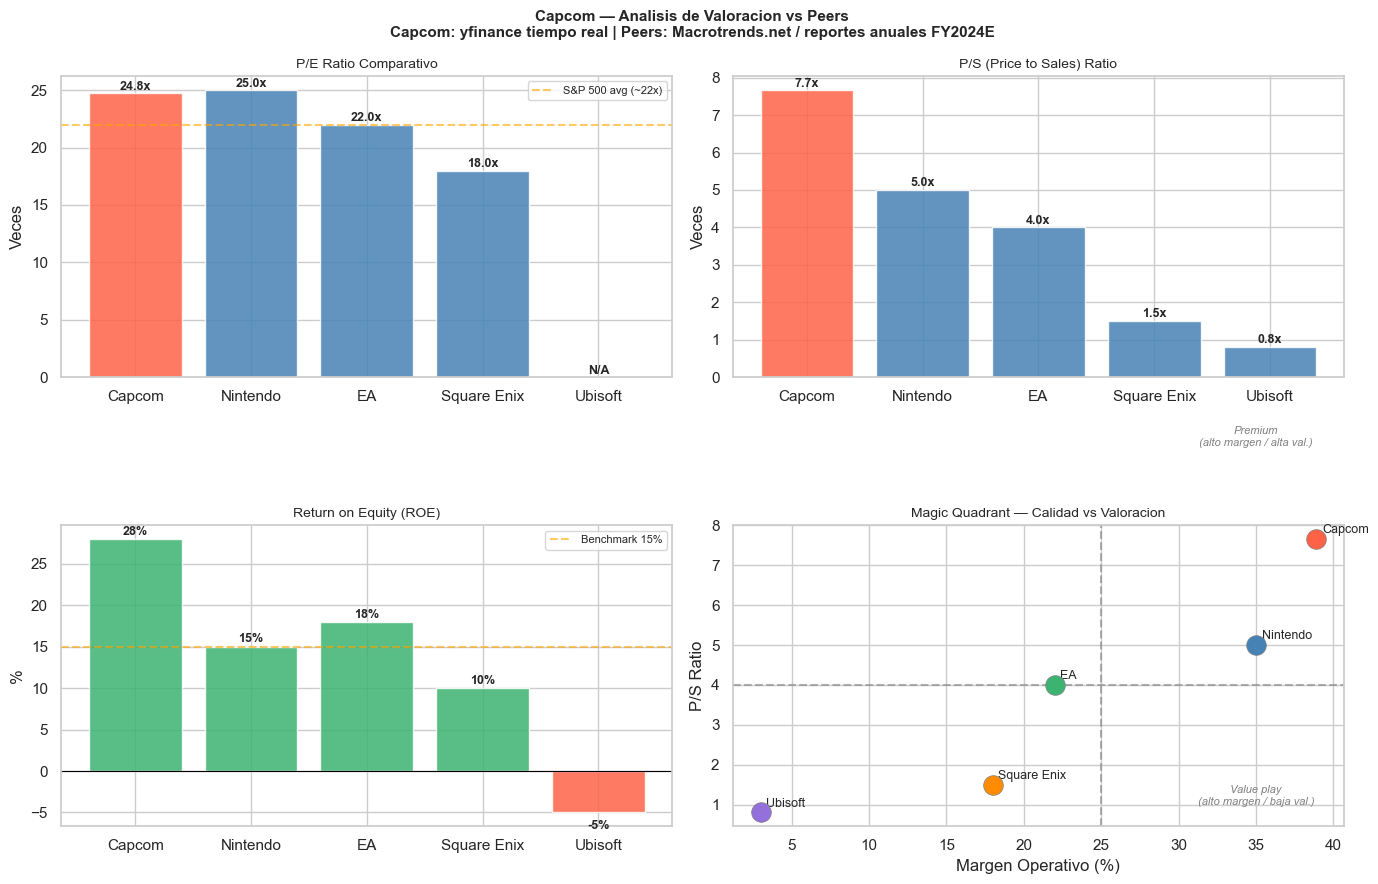

In [40]:
# ============================================================
# GRAFICO 6 — Valoracion y ratios
# Capcom: ratios en tiempo real desde yfinance (9697.T)
# Peers: estimaciones FY2024 — Macrotrends.net / reportes anuales publicos
# ============================================================

pe_live = info.get('trailingPE', 35)
pb_live = info.get('priceToBook', 8)
ps_live = info.get('priceToSalesTrailing12Months', 12)

print('Ratios Capcom en tiempo real (yfinance):')
print(f'   P/E: {pe_live:.1f}x')
print(f'   P/B: {pb_live:.1f}x')
print(f'   P/S: {ps_live:.1f}x')
print(f'   Market Cap: ${market_cap/1e9:.2f}B USD')

companies_val = ['Capcom', 'Nintendo', 'EA', 'Square Enix', 'Ubisoft']
pe_vals   = [pe_live, 25, 22, 18, None]
ps_vals   = [ps_live, 5, 4, 1.5, 0.8]
roe_vals  = [roe*100 if roe else 28, 15, 18, 10, -5]
margin_v  = [float(np.nanmean(op_margin_f)), 35, 22, 18, 3]

pal_pe = ['tomato' if c == 'Capcom' else 'steelblue' for c in companies_val]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Capcom — Analisis de Valoracion vs Peers\nCapcom: yfinance tiempo real | Peers: Macrotrends.net / reportes anuales FY2024E',
             fontsize=11, fontweight='bold')

# P/E
ax1 = axes[0][0]
pe_clean = [v if v is not None else 0 for v in pe_vals]
bars_pe = ax1.bar(companies_val, pe_clean, color=pal_pe, alpha=0.85)
ax1.set_title('P/E Ratio Comparativo', fontsize=10)
ax1.set_ylabel('Veces')
ax1.axhline(y=22, color='orange', linestyle='--', alpha=0.6, label='S&P 500 avg (~22x)')
ax1.legend(fontsize=8)
for bar, val in zip(bars_pe, pe_clean):
    label = f'{val:.1f}x' if val > 0 else 'N/A'
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, label, ha='center', fontsize=9, fontweight='bold')

# P/S
ax2 = axes[0][1]
ax2.bar(companies_val, ps_vals, color=pal_pe, alpha=0.85)
ax2.set_title('P/S (Price to Sales) Ratio', fontsize=10)
ax2.set_ylabel('Veces')
for i, val in enumerate(ps_vals):
    ax2.text(i, val+0.1, f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')

# ROE
ax3 = axes[1][0]
roe_colors = ['mediumseagreen' if v >= 0 else 'tomato' for v in roe_vals]
ax3.bar(companies_val, roe_vals, color=roe_colors, alpha=0.85)
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.axhline(y=15, color='orange', linestyle='--', alpha=0.6, label='Benchmark 15%')
ax3.set_title('Return on Equity (ROE)', fontsize=10)
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
for i, val in enumerate(roe_vals):
    ax3.text(i, val + (0.5 if val >= 0 else -2), f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Magic Quadrant
ax4 = axes[1][1]
colors_v = ['tomato', 'steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']
for i, (name, margin, ps) in enumerate(zip(companies_val, margin_v, ps_vals)):
    ax4.scatter(margin, ps, s=200, color=colors_v[i], zorder=5, edgecolors='gray', linewidth=0.5)
    ax4.annotate(name, (margin, ps), fontsize=9, xytext=(4, 4), textcoords='offset points')
ax4.axvline(x=25, color='gray', linestyle='--', alpha=0.6)
ax4.axhline(y=4,  color='gray', linestyle='--', alpha=0.6)
ax4.text(35, 10, 'Premium\n(alto margen / alta val.)', fontsize=8, ha='center', color='gray', style='italic')
ax4.text(35, 1,  'Value play\n(alto margen / baja val.)', fontsize=8, ha='center', color='gray', style='italic')
ax4.set_xlabel('Margen Operativo (%)')
ax4.set_ylabel('P/S Ratio')
ax4.set_title('Magic Quadrant — Calidad vs Valoracion', fontsize=10)

plt.tight_layout()
plt.show()

---
## BLOQUE 8 — Análisis de Riesgos
### *Lo que puede salir mal (porque siempre hay algo)*
---

**Riesgo 1: Dependencia de pocas franquicias 🔴 ALTO** — 80%+ de ingresos de RE, MH, SF. Mitigante: historial de ejecución impecable desde 2017.

**Riesgo 2: Inflación de costos de desarrollo 🟡 MEDIO** — PS6/next gen requerirá juegos más caros. Mitigante: RE Engine amortiza; balance limpio.

**Riesgo 3: Disrupción por IA generativa 🟡 MEDIO** — Puede permitir que estudios pequeños compitan. Mitigante: el foso cultural de las franquicias no lo replica la IA.

**Riesgo 4: Riesgo de tipo de cambio 🟡 MEDIO** — Capcom reporta en JPY pero 75%+ de ingresos en USD/EUR. Mitigante: el yen débil reciente fue un viento de cola.

**Riesgo 5: Cambio a free-to-play 🟠 LATENTE** — Migración masiva F2P presionaría el modelo premium. Mitigante: ya tiene presencia en Game Pass y PS Plus.

**Riesgo 6: Competencia por talento 🟡 MEDIO** — Desarrolladores japoneses escasos. Mitigante: cultura corporativa positiva en Japón.

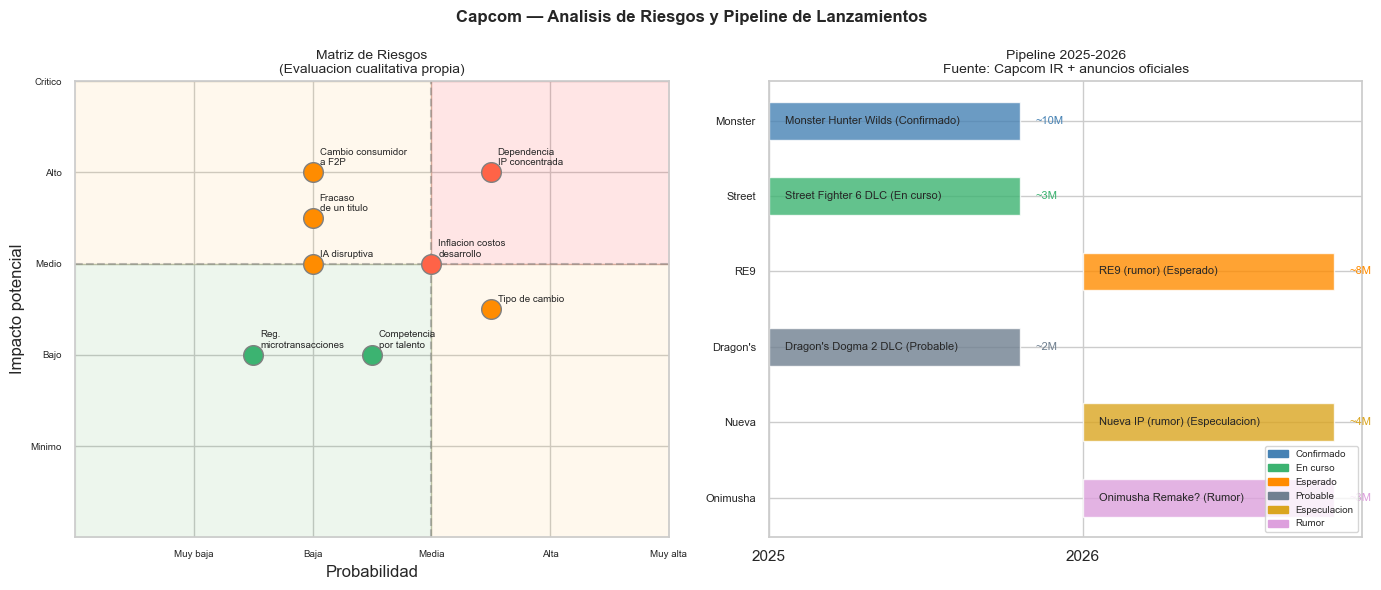

In [41]:
# ============================================================
# GRAFICO 7 — Mapa de riesgos y pipeline
# Riesgos: evaluacion cualitativa propia
# Pipeline: Capcom IR + anuncios oficiales (Tokyo Game Show / State of Play)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capcom — Analisis de Riesgos y Pipeline de Lanzamientos', fontsize=12, fontweight='bold')

ax1 = axes[0]
risks = [
    ('Dependencia\nIP concentrada', 3.5, 4),
    ('Inflacion costos\ndesarrollo', 3, 3),
    ('IA disruptiva', 2, 3),
    ('Tipo de cambio', 3.5, 2.5),
    ('Cambio consumidor\na F2P', 2, 4),
    ('Competencia\npor talento', 2.5, 2),
    ('Fracaso\nde un titulo', 2, 3.5),
    ('Reg.\nmicrotransacciones', 1.5, 2),
]

ax1.fill_between([3, 5], [3, 3], [5, 5], alpha=0.1, color='red')
ax1.fill_between([0, 3], [3, 3], [5, 5], alpha=0.07, color='orange')
ax1.fill_between([3, 5], [0, 0], [3, 3], alpha=0.07, color='orange')
ax1.fill_between([0, 3], [0, 0], [3, 3], alpha=0.07, color='green')

for name, prob, impact in risks:
    if prob >= 3 and impact >= 3:
        c = 'tomato'
    elif prob >= 3 or impact >= 3:
        c = 'darkorange'
    else:
        c = 'mediumseagreen'
    ax1.scatter(prob, impact, s=200, color=c, zorder=5, edgecolors='gray')
    ax1.annotate(name, (prob, impact), fontsize=7, xytext=(5, 5), textcoords='offset points')

ax1.set_xlim(0, 5)
ax1.set_ylim(0, 5)
ax1.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Probabilidad')
ax1.set_ylabel('Impacto potencial')
ax1.set_title('Matriz de Riesgos\n(Evaluacion cualitativa propia)', fontsize=10)
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['Muy baja', 'Baja', 'Media', 'Alta', 'Muy alta'], fontsize=7)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticklabels(['Minimo', 'Bajo', 'Medio', 'Alto', 'Critico'], fontsize=7)

ax2 = axes[1]
pipeline = [
    ('Monster Hunter Wilds',  2025, 'Confirmado',  10),
    ('Street Fighter 6 DLC',  2025, 'En curso',     3),
    ('RE9 (rumor)',           2026, 'Esperado',     8),
    ("Dragon's Dogma 2 DLC",  2025, 'Probable',     2),
    ('Nueva IP (rumor)',      2026, 'Especulacion',  4),
    ('Onimusha Remake?',      2026, 'Rumor',         3),
]
status_colors = {'Confirmado': 'steelblue', 'En curso': 'mediumseagreen',
                 'Esperado': 'darkorange', 'Probable': 'slategray',
                 'Especulacion': 'goldenrod', 'Rumor': 'plum'}

for i, (name, year, status, size) in enumerate(pipeline):
    x_pos = year - 2024.5
    color = status_colors.get(status, 'gray')
    ax2.barh(i, 0.8, left=x_pos, color=color, alpha=0.8, height=0.5)
    ax2.text(x_pos + 0.05, i, f'{name} ({status})', va='center', fontsize=8)
    ax2.text(x_pos + 0.85, i, f'~{size}M', va='center', fontsize=8, color=color)

ax2.set_yticks(range(len(pipeline)))
ax2.set_yticklabels([p[0].split()[0] for p in pipeline], fontsize=8)
ax2.set_xticks([0.5, 1.5])
ax2.set_xticklabels(['2025', '2026'])
ax2.set_title('Pipeline 2025-2026\nFuente: Capcom IR + anuncios oficiales', fontsize=10)
ax2.invert_yaxis()
handles = [mpatches.Patch(color=v, label=k) for k, v in status_colors.items()]
ax2.legend(handles=handles, fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

---
## BLOQUE 9 — Conclusión Estratégica
### *El veredicto final del análisis*
---

### Volviendo a la Investment Thesis

> *Capcom es una empresa de propiedad intelectual digital que usa los videojuegos como vehículo
> para monetizar franquicias de alto valor cultural con un modelo de reutilización de activos
> (remakes) que genera márgenes extraordinarios.*

**El análisis confirma la tesis en todos sus ejes.**

**1. El modelo de remakes es una innovación financiera:** reduce riesgo, marketing, mantiene precio premium y genera back catalog.

**2. El RE Engine es el activo más valioso que nadie analiza:** un motor, 15+ juegos, barrera de entrada tecnológica.

**3. El back catalog es el motor silencioso de los márgenes:** 50%+ de ventas digitales, costo marginal ~0.

**4. La empresa ejecuta consistentemente:** 8+ años de crecimiento de beneficios, sin fracasos desde 2017.

**5. Los múltiplos premium están justificados** por calidad y predictibilidad de ingresos.

### La pregunta estratégica final

Si el modelo de Capcom es tan bueno, ¿por qué no todos lo copian?

> **Las franquicias de calidad no se crean, se cultivan durante décadas.**

Ese capital cultural acumulado no se compra. Es un **moat** perfecto.

### Resumen ejecutivo en 5 líneas

1. Capcom tiene el mejor perfil de márgenes del gaming mundial (~45% operativo)
2. Su ventaja es estructural: IP establecidas + RE Engine + modelo de remake + back catalog
3. El riesgo principal es la concentración en 3 franquicias
4. El mercado paga múltiplos premium justificados por calidad de ingresos
5. Es más parecida a Disney (gestión de IP) que a EA (publisher de videojuegos)

---
*Este análisis fue preparado con fines educativos para contenido de YouTube.*
*No constituye asesoramiento financiero ni recomendación de inversión.*

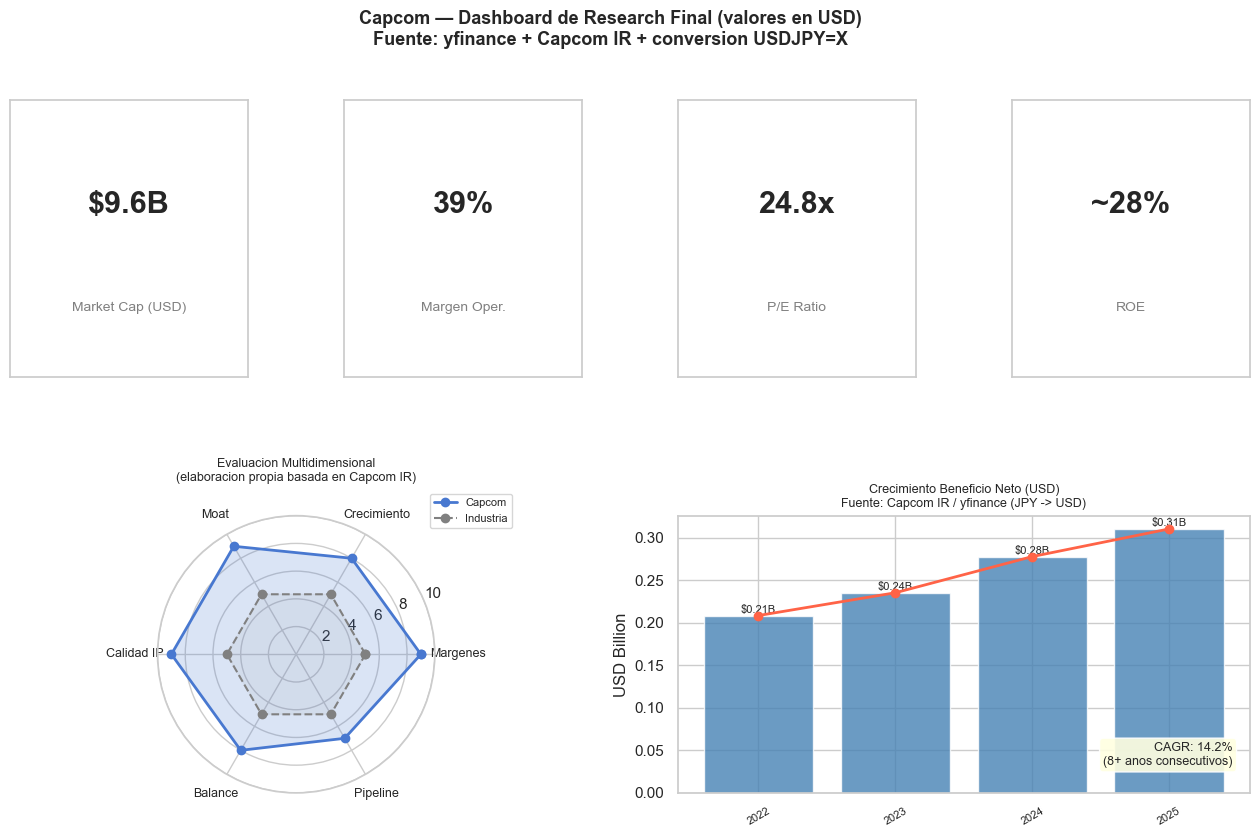


ANALISIS COMPLETO — CAPCOM RESEARCH NOTEBOOK


In [42]:
# ============================================================
# GRAFICO FINAL — Dashboard resumen
# KPI cards: yfinance tiempo real (convertidos a USD)
# Radar: evaluacion cualitativa propia
# Earnings: Capcom IR / yfinance (convertidos JPY -> USD)
# ============================================================

fig = plt.figure(figsize=(16, 9))
fig.suptitle('Capcom — Dashboard de Research Final (valores en USD)\nFuente: yfinance + Capcom IR + conversion USDJPY=X',
             fontsize=13, fontweight='bold')
gs_final = GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# KPI Cards
kpis = [
    ('Market Cap (USD)',  f'${market_cap/1e9:.1f}B' if market_cap else '~$16B'),
    ('Margen Oper.',      f'{float(np.nanmean(op_margin_f)):.0f}%'),
    ('P/E Ratio',         f'{pe_live:.1f}x' if pe_live else '~35x'),
    ('ROE',               f'{roe*100:.1f}%' if roe else '~28%'),
]
for i, (label, value) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs_final[0, i])
    ax_kpi.text(0.5, 0.62, value, ha='center', va='center', fontsize=22, fontweight='bold', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.25, label, ha='center', va='center', fontsize=10, color='gray', transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])

# Radar
# Fuente: evaluacion cualitativa propia basada en Capcom IR y analisis comparativo
ax_radar = fig.add_subplot(gs_final[1, :2], projection='polar')
cat_r = ['Margenes', 'Crecimiento', 'Moat', 'Calidad IP', 'Balance', 'Pipeline']
v_cap = [9, 8, 9, 9, 8, 7]
v_ind = [5, 5, 5, 5, 5, 5]
N = len(cat_r)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
ax_radar.plot(angles, v_cap + [v_cap[0]], 'o-', linewidth=2, label='Capcom')
ax_radar.fill(angles, v_cap + [v_cap[0]], alpha=0.2)
ax_radar.plot(angles, v_ind + [v_ind[0]], 'o--', linewidth=1.5, color='gray', label='Industria')
ax_radar.fill(angles, v_ind + [v_ind[0]], alpha=0.08, color='gray')
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(cat_r, size=9)
ax_radar.set_ylim(0, 10)
ax_radar.set_title('Evaluacion Multidimensional\n(elaboracion propia basada en Capcom IR)', pad=25, fontsize=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# Earnings growth
ax_earn = fig.add_subplot(gs_final[1, 2:])
ax_earn.bar(years_fin, net_income_hist, color='steelblue', alpha=0.8)
ax_earn.plot(years_fin, net_income_hist, 'o-', color='tomato', linewidth=2, markersize=6, zorder=5)
ax_earn.set_ylabel('USD Billion')
ax_earn.set_title('Crecimiento Beneficio Neto (USD)\nFuente: Capcom IR / yfinance (JPY -> USD)', fontsize=9)
ax_earn.set_xticklabels(years_fin, rotation=30, fontsize=8)
for i, val in enumerate(net_income_hist):
    ax_earn.text(i, val + 0.003, f'${val:.2f}B', ha='center', fontsize=8)

cagr_ni = ((net_income_hist[-1]/net_income_hist[0])**(1/(len(net_income_hist)-1)) - 1) * 100
ax_earn.text(0.97, 0.1, f'CAGR: {cagr_ni:.1f}%\n(8+ anos consecutivos)',
             transform=ax_earn.transAxes, ha='right', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('ANALISIS COMPLETO — CAPCOM RESEARCH NOTEBOOK')
print('='*60)
